In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)
RANDOM_STATE = 42
sns.set_style("whitegrid")


In [3]:
train_path = "customer_churn_dataset-training-master.csv"
test_path = "customer_churn_dataset-testing-master.csv"
train_df = pd.read_csv(train_path)
try:
    test_df = pd.read_csv(test_path)
    df = pd.concat([train_df, test_df], ignore_index=True)
    print(f"Loaded training ({train_df.shape}) + testing ({test_df.shape}) files -> combined {df.shape}")
except FileNotFoundError:
    df = train_df.copy()
    print(f"Loaded training file only -> {df.shape}")
df.head()

Loaded training ((440833, 12)) + testing ((64374, 12)) files -> combined (505207, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [4]:
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nChurn distribution:")
print(df["Churn"].value_counts(normalize=True))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 46.3+ MB
None

Missing values per column:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Su

In [5]:
df = df.dropna().reset_index(drop=True)
df = df.drop(columns=["CustomerID"])
df["Churn"] = df["Churn"].astype(int)

categorical_cols = ["Gender", "Subscription Type", "Contract Length"]
numeric_cols = [c for c in df.columns if c not in categorical_cols + ["Churn"]]

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

print(df.dtypes)
df.head()


Age                  float64
Gender                 int64
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type      int64
Contract Length        int64
Total Spend          float64
Last Interaction     float64
Churn                  int64
dtype: object


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,0,39.0,14.0,5.0,18.0,2,0,932.0,17.0,1
1,65.0,0,49.0,1.0,10.0,8.0,0,1,557.0,6.0,1
2,55.0,0,14.0,4.0,6.0,18.0,0,2,185.0,3.0,1
3,58.0,1,38.0,21.0,7.0,7.0,2,1,396.0,29.0,1
4,23.0,1,32.0,20.0,5.0,8.0,0,1,617.0,20.0,1


In [6]:
X = df.drop(columns=["Churn"])
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (404164, 10), Test shape: (101042, 10)


In [7]:
def evaluate_model(name, model, X_te, y_te, results_dict):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1 Score": f1_score(y_te, y_pred),
        "ROC AUC": roc_auc_score(y_te, y_proba),
    }
    results_dict[name] = metrics

    print(f"=== {name} ===")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred))

    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return metrics

results = {}

=== Baseline (Logistic Regression) ===
Accuracy: 0.8196
Precision: 0.8448
Recall: 0.8271
F1 Score: 0.8359
ROC AUC: 0.8874

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80     44943
           1       0.84      0.83      0.84     56099

    accuracy                           0.82    101042
   macro avg       0.82      0.82      0.82    101042
weighted avg       0.82      0.82      0.82    101042



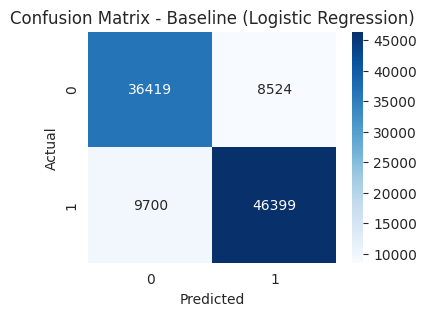

In [8]:
baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_model.fit(X_train_scaled, y_train)
baseline_metrics = evaluate_model("Baseline (Logistic Regression)", baseline_model, X_test_scaled, y_test, results)

In [9]:
from sklearn.model_selection import train_test_split

X_tune, _, y_tune, _ = train_test_split(
    X_train_scaled, y_train, train_size=30000, stratify=y_train, random_state=RANDOM_STATE
)

param_dist = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

rf = RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(
    estimator=rf, param_distributions=param_dist, n_iter=10,
    scoring="f1", cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=2,
)

random_search.fit(X_tune, y_tune)
print("Best hyperparameters found:")
print(random_search.best_params_)
print(f"Best CV F1 score: {random_search.best_score_:.4f}")

optimized_model = RandomForestClassifier(**random_search.best_params_, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1)
optimized_model.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best hyperparameters found:
{'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}
Best CV F1 score: 0.9415


RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=150,
                       n_jobs=-1, random_state=42)

=== Optimized (Random Forest) ===
Accuracy: 0.9357
Precision: 0.8984
Recall: 0.9969
F1 Score: 0.9451
ROC AUC: 0.9531

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92     44943
           1       0.90      1.00      0.95     56099

    accuracy                           0.94    101042
   macro avg       0.95      0.93      0.93    101042
weighted avg       0.94      0.94      0.94    101042



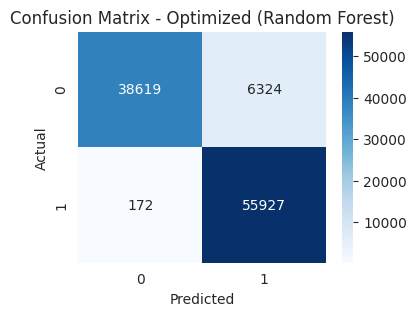

In [10]:
optimized_metrics = evaluate_model("Optimized (Random Forest)", optimized_model, X_test_scaled, y_test, results)

                                Accuracy  Precision    Recall  F1 Score  \
Baseline (Logistic Regression)  0.819639   0.844801  0.827091  0.835852   
Optimized (Random Forest)       0.935710   0.898411  0.996934  0.945112   

                                 ROC AUC  
Baseline (Logistic Regression)  0.887450  
Optimized (Random Forest)       0.953132  


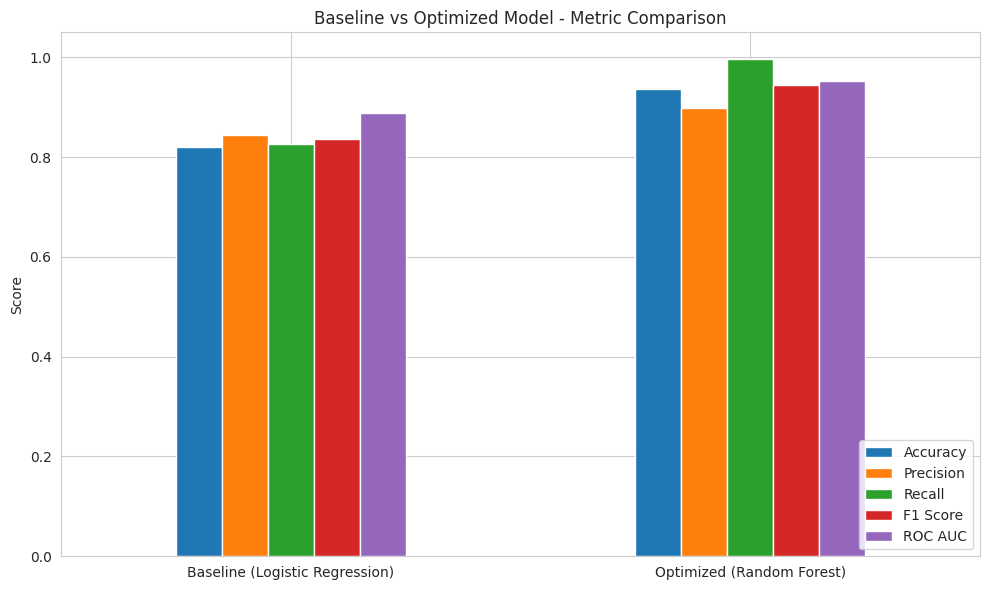

In [11]:
comparison_df = pd.DataFrame(results).T
print(comparison_df)
comparison_df.plot(kind="bar", figsize=(10, 6))
plt.title("Baseline vs Optimized Model - Metric Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

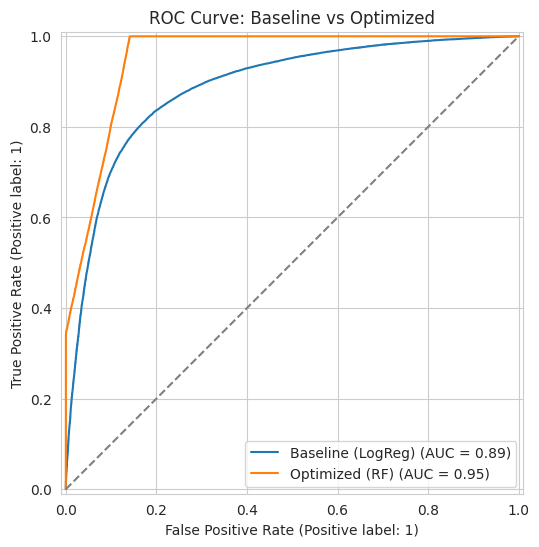

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_estimator(baseline_model, X_test_scaled, y_test, ax=ax, name="Baseline (LogReg)")
RocCurveDisplay.from_estimator(optimized_model, X_test_scaled, y_test, ax=ax, name="Optimized (RF)")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("ROC Curve: Baseline vs Optimized")
plt.show()



/tmp/ipykernel_922/146988951.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


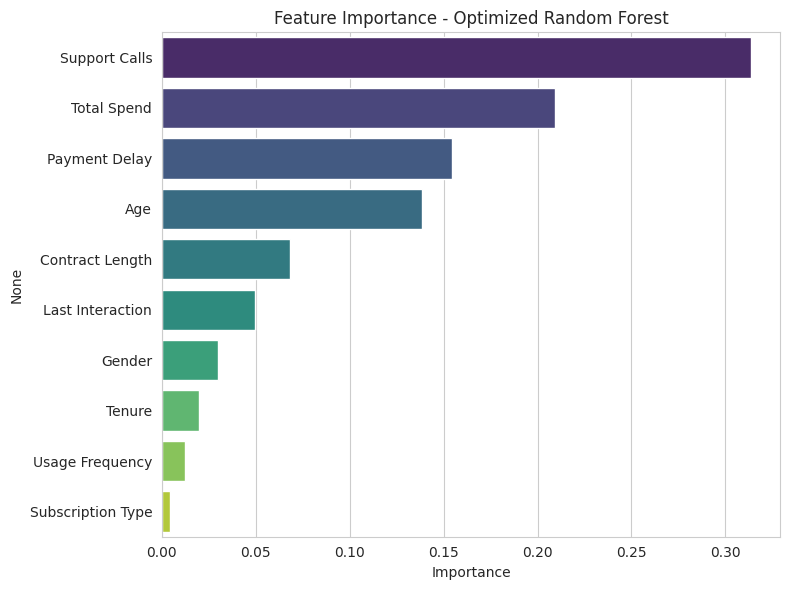

Top features driving churn:
Support Calls        0.313419
Total Spend          0.209436
Payment Delay        0.154636
Age                  0.138550
Contract Length      0.068276
Last Interaction     0.049456
Gender               0.029809
Tenure               0.019919
Usage Frequency      0.012380
Subscription Type    0.004119
dtype: float64


In [13]:
importances = pd.Series(optimized_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importance - Optimized Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
print("Top features driving churn:")
print(importances)

In [14]:
improvement = {
    metric: optimized_metrics[metric] - baseline_metrics[metric]
    for metric in baseline_metrics
}
print("Performance change (Optimized - Baseline):")
for metric, delta in improvement.items():
    print(f"{metric}: {delta:+.4f}")
top_features = importances.head(5)
print("\n--- Summary ---")
print(f"The optimized Random Forest model (tuned via RandomizedSearchCV) improved F1 score "
      f"from {baseline_metrics['F1 Score']:.4f} to {optimized_metrics['F1 Score']:.4f} "
      f"and ROC AUC from {baseline_metrics['ROC AUC']:.4f} to {optimized_metrics['ROC AUC']:.4f} "
      f"compared to the baseline Logistic Regression model.")
print(f"\nTop 5 factors influencing churn: {', '.join(top_features.index.tolist())}")
print("\nRecommendations:")
print("- Prioritize retention outreach for customers with high Support Calls and Payment Delay.")
print("- Monitor customers with declining Usage Frequency / low Total Spend as early churn signals.")
print("- Offer incentives around contract renewal periods, since Contract Length is a strong predictor.")

Performance change (Optimized - Baseline):
Accuracy: +0.1161
Precision: +0.0536
Recall: +0.1698
F1 Score: +0.1093
ROC AUC: +0.0657

--- Summary ---
The optimized Random Forest model (tuned via RandomizedSearchCV) improved F1 score from 0.8359 to 0.9451 and ROC AUC from 0.8874 to 0.9531 compared to the baseline Logistic Regression model.

Top 5 factors influencing churn: Support Calls, Total Spend, Payment Delay, Age, Contract Length

Recommendations:
- Prioritize retention outreach for customers with high Support Calls and Payment Delay.
- Monitor customers with declining Usage Frequency / low Total Spend as early churn signals.
- Offer incentives around contract renewal periods, since Contract Length is a strong predictor.
